# Working with S2 in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/02_s2.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/02_s2.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/02_s2.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/02_s2.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid

In [ ]:
# %pip install vgrid --upgrade

### latlon2s2

In [2]:
from vgrid.conversion.latlon2dggs import latlon2s2

lat = 10.775276
lon = 106.706797
res = 2
s2_token = latlon2s2(lat, lon, res)
s2_token

'31'

### S2 to Polygon

In [ ]:
from vgrid.conversion.dggs2geo.s22geo import s22geo

s2_geo = s22geo(s2_token)
s2_geo

### S2 to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.s22geo import s22geojson

s2_geojson = s22geojson(s2_token)
# s2_geojson

### Vector to S2

#### Multi(Point) to S2

In [ ]:
from vgrid.conversion.vector2dggs.vector2s2 import vector2s2
import geopandas as gpd

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"
)

gdf = gpd.read_file(file_path)

point_to_s2 = vector2s2(
    gdf,
    # resolution = 15,
    topology=True,
    output_format="gpd", verbose=True,
)
# point_to_s2
point_to_s2.plot()

#### Multi(Polyline) to S2

Processing features: 100%|██████████| 7/7 [00:00<00:00, 56.99it/s]


<Axes: >

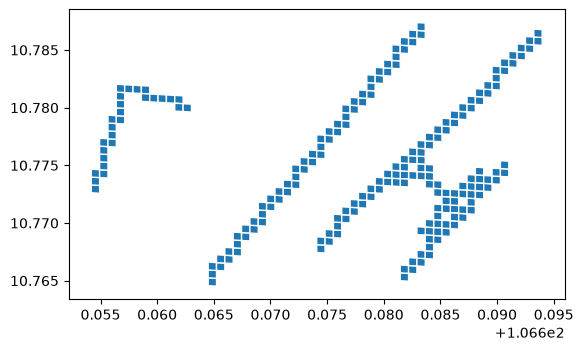

In [5]:
from vgrid.conversion.vector2dggs.vector2s2 import vector2s2

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polyline.geojson"
vector_to_s2 = vector2s2(
    file_path,
    resolution=17,
    output_format="gpd", verbose=True,
)
# Visualize vector_to_s2
vector_to_s2.plot(edgecolor="white")

#### Multi(Polygon) to S2

Processing features: 100%|██████████| 1/1 [00:00<00:00,  4.92it/s]


<Axes: >

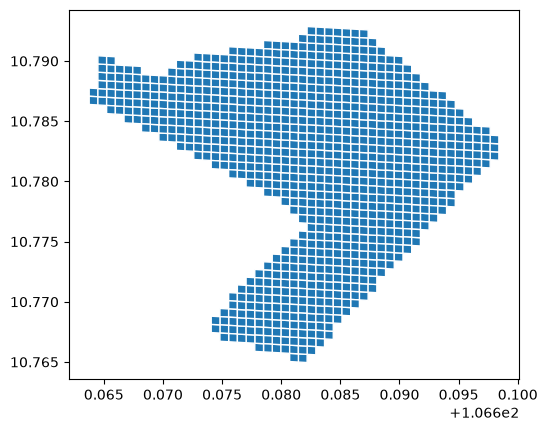

In [6]:
from vgrid.conversion.vector2dggs.vector2s2 import vector2s2

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_s2 = vector2s2(
    file_path,
    resolution=17,
    compact=False,
    depth=-1,  # used when compact=True; -1: full compact
    predicate="intersects",
    output_format="gpd", verbose=True,
)
# Visualize vector_to_s2
vector_to_s2.plot(edgecolor="white")

### S2 Compact

In [ ]:
from vgrid.conversion.dggscompact.s2compact import s2compact

s2_compacted = s2compact(vector_to_s2, s2_token="s2", depth=-1, output_format="gpd", verbose=True)
s2_compacted.plot(edgecolor="white")

### S2 Expand

In [ ]:
from vgrid.conversion.dggscompact.s2compact import s2expand

s2_expanded = s2expand(vector_to_s2, resolution=19,  # if set, depth is ignored
    # depth=1,  # 1: children
    output_format="gpd", verbose=True)
s2_expanded.plot(edgecolor="white")

### S2 Binning

In [ ]:
from vgrid.binning.s2bin import s2bin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
agg = "max"
numeric_col = "median_house_value"
s2_bin = s2bin(
    file_path,
    resolution=9,
    agg=agg,
    numeric_col=numeric_col,
    # category_col="category",
    output_format="gpd", verbose=True,
)
s2_bin.plot(
    column=f"{numeric_col}_{agg}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### S2 Resampling

In [ ]:
from vgrid.conversion.dggsresample import dggsresample

s2_resample = dggsresample(
    source_dggs=s2_bin,
    dggs_from="s2",
    dggs_to="a5",
    method="nearest",  # area_weighted, nearest
    dggs_col="s2",
    resample_col=f"{numeric_col}_{agg}",  # column on h3_bin with numbers
    fix_antimeridian=None,
    split_antimeridian=False,
    verbose=True,
)
s2_resample.plot(
    column=f"{numeric_col}_{agg}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to S2

#### Download and open raster

In [ ]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to S2

In [ ]:
# %pip install folium

In [ ]:
from vgrid.conversion.raster2dggs.raster2s2 import raster2s2


raster_to_s2 = raster2s2(
    raster_file,
    method="nearest",  # nearest, binning
    stats="mean",
    output_format="gpd", verbose=True,
)
# Visualize raster_to_s2
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

s2_layer = folium.GeoJson(
    raster_to_s2,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["s2", "resolution", "band_1", "band_2", "band_3", "cell_area"],
        aliases=["S2 Token", "Resolution", "Band 1", "Band 2", "Band 3", "Area (m²)"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(s2_layer.get_bounds())

# Display the map
m

### S2 Generator

In [ ]:
from vgrid.generator.s2grid import s2grid

# s2_grid = s2grid(resolution=2, output_format="gpd", compact = True, fix_antimeridian="shift_east")
s2_grid = s2grid(
    resolution=16,
    bbox=[106.699007, 10.762811, 106.717674, 10.778649],
    compact=True,
    output_format="gpd", verbose=True,
)
# s2_grid.to_crs('proj=moll').plot(edgecolor="white")
s2_grid.plot(edgecolor="white")

### S2 Inspect

In [ ]:
from vgrid.stats.s2stats import s2inspect

resolution = 6
s2_inspect = s2inspect(resolution, verbose=True)
s2_inspect.head()

### S2 Normalized Area Histogram

In [ ]:
from vgrid.stats.s2stats import s2_norm_area_hist

s2_norm_area_hist(s2_inspect)

### Distribution of S2 Area Distortions

In [ ]:
from vgrid.stats.s2stats import s2_norm_area

s2_norm_area(s2_inspect)

### S2 IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is (0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.


In [ ]:
from vgrid.stats.s2stats import s2_compactness_ipq_hist

s2_compactness_ipq_hist(s2_inspect)

### Distribution of S2 IPQ Compactness

In [ ]:
from vgrid.stats.s2stats import s2_compactness_ipq

s2_compactness_ipq(s2_inspect)

### S2 Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is (0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

In [ ]:
from vgrid.stats.s2stats import s2_compactness_cvh_hist

s2_compactness_cvh_hist(s2_inspect)

### Distribution of S2 Convex hull Compactness

In [ ]:
from vgrid.stats.s2stats import s2_compactness_cvh

s2_compactness_cvh(s2_inspect)

### S2 Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [ ]:
from vgrid.stats.s2stats import s2stats

s2stats()